In [2]:
library(mixOmics)

In [5]:
data(breast.TCGA)

In [70]:
cat("

The data were divided into a training set with a subset of 150 samples from the mRNA, miRNA and proteomics data, 
and a test set includes 70 samples, but only from the mRNA, miRNA and methylation data (proteomics missing).

The mixOmics TCGA dataset is accessed via `breast.TCGA’ and contains the following:

breast.TCGA$data.train$mirna (continuous matrix): 150 rows and 184 columns. The expression levels of 184 different sections of miRNA.

breast.TCGA$data.train$mrna (continuous matrix): 150 rows and 200 columns. The expression levels of 200 different sections of mRNA.

breast.TCGA$data.train$protein (continuous matrix): 150 rows and 142 columns. The abundance of 142 different proteins

breast.TCGA$data.train$subtype (categorical vector): length of 150. 

Indicates the breast cancer subtype of each subject. Includes Basal, Her2 and LumA.

")



The data were divided into a training set with a subset of 150 samples from the mRNA, miRNA and proteomics data, 
and a test set includes 70 samples, but only from the mRNA, miRNA and methylation data (proteomics missing).

The mixOmics TCGA dataset is accessed via `breast.TCGA’ and contains the following:

breast.TCGA$data.train$mirna (continuous matrix): 150 rows and 184 columns. The expression levels of 184 different sections of miRNA.

breast.TCGA$data.train$mrna (continuous matrix): 150 rows and 200 columns. The expression levels of 200 different sections of mRNA.

breast.TCGA$data.train$protein (continuous matrix): 150 rows and 142 columns. The abundance of 142 different proteins

breast.TCGA$data.train$subtype (categorical vector): length of 150. 

Indicates the breast cancer subtype of each subject. Includes Basal, Her2 and LumA.



In [89]:
cat("

What is a Multi-Block Model?

A multi-block model integrates multiple datasets (blocks) simultaneously rather than analyzing them separately or in pairs.

Key Differences:

Pairwise approach (lines 26-31 in your script):

Analyzes miRNA vs mRNA
Then miRNA vs proteomics
Then mRNA vs proteomics

3 separate models, each ignoring the third dataset

Multi-block approach (DIABLO, line 86):

Analyzes miRNA + mRNA + proteomics all at once
Finds components that maximize:

Correlation between all datasets (as specified in design matrix)
Discrimination between cancer subtypes

An integrated model that considers all relationships simultaneously :

Why is this better?

Imagine you're trying to understand a disease:

Pairwise: You look at genes, then proteins, then metabolites separately
Multi-block: You see how genes, proteins, AND metabolites work together as a system

Multi-block captures synergistic effects that pairwise analysis misses. For example:

A gene change might only affect cancer subtype when combined with specific protein and miRNA changes
Multi-block finds these coordinated multi-omics signatures

")



What is a Multi-Block Model?

A multi-block model integrates multiple datasets (blocks) simultaneously rather than analyzing them separately or in pairs.

Key Differences:

Pairwise approach (lines 26-31 in your script):

Analyzes miRNA vs mRNA
Then miRNA vs proteomics
Then mRNA vs proteomics

3 separate models, each ignoring the third dataset

Multi-block approach (DIABLO, line 86):

Analyzes miRNA + mRNA + proteomics all at once
Finds components that maximize:

Correlation between all datasets (as specified in design matrix)
Discrimination between cancer subtypes

An integrated model that considers all relationships simultaneously :

Why is this better?

Imagine you're trying to understand a disease:

Pairwise: You look at genes, then proteins, then metabolites separately
Multi-block: You see how genes, proteins, AND metabolites work together as a system

Multi-block captures synergistic effects that pairwise analysis misses. For example:

A gene change might only affect cancer sub

In [72]:
head(breast.TCGA$data.train$mirna, 3)
dim(breast.TCGA$data.train$mirna)

,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,hsa-let-7g,⋯,hsa-mir-9-1,hsa-mir-9-2,hsa-mir-92a-1,hsa-mir-92a-2,hsa-mir-92b,hsa-mir-93,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
A0FJ,11.83582,12.85105,11.91881,14.80138,10.93568,9.871200,10.489443,5.508567,11.23100,10.921689,⋯,12.747092,12.779765,11.320936,15.28878,5.832308,13.27279,6.920198,6.651011,8.745468,15.78373
A13E,12.89793,13.90087,12.91273,14.71551,12.03184,9.599494,10.423508,4.563071,12.61597,9.679918,⋯,13.831421,13.823930,12.098454,14.26268,6.900878,14.08633,6.292604,6.329947,9.235832,14.90278
A0G0,12.30773,13.29032,12.30062,15.06619,10.93393,10.402871,8.422631,4.880635,11.27174,9.187242,⋯,6.182099,6.544669,9.040364,13.92461,4.563778,13.51148,5.330801,5.910797,9.333587,13.66121


[1] 150 184

In [73]:
head(breast.TCGA$data.train$mrna, 3)
dim(breast.TCGA$data.train$mrna)

,RTN2,NDRG2,CCDC113,FAM63A,ACADS,GMDS,HLA-H,SEMA4A,ETS2,LIMD2,⋯,ELP2,ALOX5,AMN1,CERCAM,SEMA3C,KRT8,TP53INP2,JAM3,ZNF680,PBX1
A0FJ,4.362183,7.533461,3.956124,4.457170,2.256817,6.017940,5.006907,3.217812,4.734446,5.099598,⋯,6.581283,2.657454,4.015401,5.155279,7.709125,11.196906,5.564430,3.991982,3.352637,7.880923
A13E,1.984492,7.455194,5.427623,5.440957,4.028813,4.341692,6.178668,2.864659,5.411029,4.211397,⋯,7.150755,2.979337,2.948135,6.071058,6.657197,9.584007,5.923025,3.343699,3.637142,7.807082
A0G0,1.727323,8.079968,2.227300,5.543480,2.629855,6.363030,6.039563,5.946028,5.651670,3.304513,⋯,6.430628,3.373541,3.063473,5.737308,3.978155,10.423796,5.980527,3.289314,3.633879,7.441712


[1] 150 200

In [ ]:
head(breast.TCGA$data.train$mirna, 3)
dim(breast.TCGA$data.train$mirna)

In [74]:
head(breast.TCGA$data.train$protein, 3)
dim(breast.TCGA$data.train$protein)

,14-3-3_epsilon,4E-BP1,4E-BP1_pS65,4E-BP1_pT37,4E-BP1_pT70,53BP1,A-Raf_pS299,ACC1,ACC_pS79,AMPK_alpha,⋯,mTOR_pS2448,p27,p27_pT157,p27_pT198,p38_MAPK,p38_pT180_Y182,p53,p70S6K,p70S6K_pT389,p90RSK_pT359_S363
A0FJ,0.04913078,0.4474862,-0.07432175,-0.3811629,0.02606943,0.91783419,0.02274147,-0.08626782,-0.4166244,0.28527039,⋯,-0.58275211,0.2168464,0.05089577,0.09527322,-0.4496626,-0.5569518,0.08102586,-0.223194866,-0.1739376,-0.1574189
A13E,-0.07998211,0.6052184,0.28891184,1.1602454,-0.01096717,0.05910121,-0.45985298,-0.59269183,-0.0622684,-0.27523360,⋯,0.21541101,0.1969638,0.18967402,0.31001694,-0.5158219,-0.3608573,0.35679190,-0.009881423,0.2926253,0.5036419
A0G0,-0.03284989,0.8946097,0.89127784,1.4001889,0.26588012,0.51704453,-0.19182192,0.41117190,0.8258286,0.06774184,⋯,0.08943085,-0.4627653,0.24890807,0.39350644,-0.4727346,-0.3578585,-0.22571943,-0.270273922,-0.1592803,0.3531037


[1] 150 142

In [78]:
length(breast.TCGA$data.train$subtype)
unique(breast.TCGA$data.train$subtype)

head(breast.TCGA$data.train$subtype)
tail(breast.TCGA$data.train$subtype)

[1] 150

[1] Basal Her2  LumA 
Levels: Basal Her2 LumA

[1] Basal Basal Basal Basal Basal Basal
Levels: Basal Her2 LumA

[1] LumA LumA LumA LumA LumA LumA
Levels: Basal Her2 LumA

In [76]:
# set a list of all the X dataframes
data = list(miRNA = breast.TCGA$data.train$mirna, 
            mRNA = breast.TCGA$data.train$mrna,
            proteomics = breast.TCGA$data.train$protein)

In [8]:
# head(data)
str(data)

List of 3
 $ miRNA     : num [1:150, 1:184] 11.8 12.9 12.3 12 13.4 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:150] "A0FJ" "A13E" "A0G0" "A0SX" ...
  .. ..$ : chr [1:184] "hsa-let-7a-1" "hsa-let-7a-2" "hsa-let-7a-3" "hsa-let-7b" ...
 $ mRNA      : num [1:150, 1:200] 4.36 1.98 1.73 4.36 2.45 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:150] "A0FJ" "A13E" "A0G0" "A0SX" ...
  .. ..$ : chr [1:200] "RTN2" "NDRG2" "CCDC113" "FAM63A" ...
 $ proteomics: num [1:150, 1:142] 0.0491 -0.08 -0.0328 -0.2053 0.0602 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:150] "A0FJ" "A13E" "A0G0" "A0SX" ...
  .. ..$ : chr [1:142] "14-3-3_epsilon" "4E-BP1" "4E-BP1_pS65" "4E-BP1_pT37" ...


In [9]:
lapply(data, dim) # check their dimensions

$miRNA
[1] 150 184

$mRNA
[1] 150 200

$proteomics
[1] 150 142

In [10]:
Y = breast.TCGA$data.train$subtype # set the response variable as the Y df
summary(Y)

Basal  Her2  LumA 
   45    30    75

In [11]:
cat("Initial Analysis")

Initial Analysis

In [12]:
cat("Pairwise PLS Comparisons")

Pairwise PLS Comparisons

In [80]:
# Specifies to keep 25 features from each dataset for components 1 and 2. This is arbitrary at this stage

list.keepX = c(25, 25) # select arbitrary values of features to keep
list.keepY = c(25, 25)

print(list.keepX)
print(list.keepY)

[1] 25 25
[1] 25 25


In [ ]:
# generate three pairwise PLS models
pls1 <- spls(data[["miRNA"]], data[["mRNA"]], 
             keepX = list.keepX, keepY = list.keepY) 

# Creates a sparse PLS model between miRNA and mRNA. Sparse PLS performs feature selection while modeling relationships.

pls2 <- spls(data[["miRNA"]], data[["proteomics"]], 
             keepX = list.keepX, keepY = list.keepY)
pls3 <- spls(data[["mRNA"]], data[["proteomics"]], 
             keepX = list.keepX, keepY = list.keepY)

# Creates two more pairwise PLS models. This helps understand bivariate relationships before the full multi-block model.

In [14]:
pls1


Call:
 spls(X = data[["miRNA"]], Y = data[["mRNA"]], keepX = list.keepX, keepY = list.keepY) 

 sPLS with a 'regression' mode with 2 sPLS components. 
 You entered data X of dimensions: 150 184 
 You entered data Y of dimensions: 150 200 

 Selection of [25] [25] variables on each of the sPLS components on the X data set. 
 Selection of [25] [25] variables on each of the sPLS components on the Y data set. 

 Main numerical outputs: 
 -------------------- 
 loading vectors: see object$loadings 
 variates: see object$variates 
 variable names: see object$names 

 Functions to visualise samples: 
 -------------------- 
 plotIndiv, plotArrow 

 Functions to visualise variables: 
 -------------------- 
 plotVar, plotLoadings, network, cim 

In [15]:
pls2


Call:
 spls(X = data[["miRNA"]], Y = data[["proteomics"]], keepX = list.keepX, keepY = list.keepY) 

 sPLS with a 'regression' mode with 2 sPLS components. 
 You entered data X of dimensions: 150 184 
 You entered data Y of dimensions: 150 142 

 Selection of [25] [25] variables on each of the sPLS components on the X data set. 
 Selection of [25] [25] variables on each of the sPLS components on the Y data set. 

 Main numerical outputs: 
 -------------------- 
 loading vectors: see object$loadings 
 variates: see object$variates 
 variable names: see object$names 

 Functions to visualise samples: 
 -------------------- 
 plotIndiv, plotArrow 

 Functions to visualise variables: 
 -------------------- 
 plotVar, plotLoadings, network, cim 

In [16]:
pls3


Call:
 spls(X = data[["mRNA"]], Y = data[["proteomics"]], keepX = list.keepX, keepY = list.keepY) 

 sPLS with a 'regression' mode with 2 sPLS components. 
 You entered data X of dimensions: 150 200 
 You entered data Y of dimensions: 150 142 

 Selection of [25] [25] variables on each of the sPLS components on the X data set. 
 Selection of [25] [25] variables on each of the sPLS components on the Y data set. 

 Main numerical outputs: 
 -------------------- 
 loading vectors: see object$loadings 
 variates: see object$variates 
 variable names: see object$names 

 Functions to visualise samples: 
 -------------------- 
 plotIndiv, plotArrow 

 Functions to visualise variables: 
 -------------------- 
 plotVar, plotLoadings, network, cim 

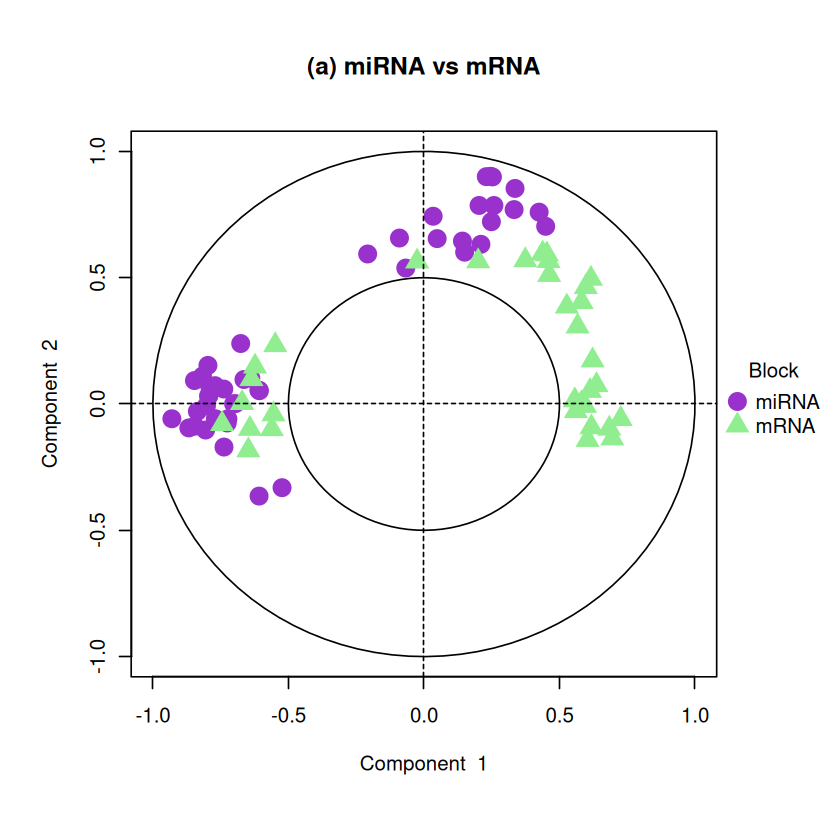

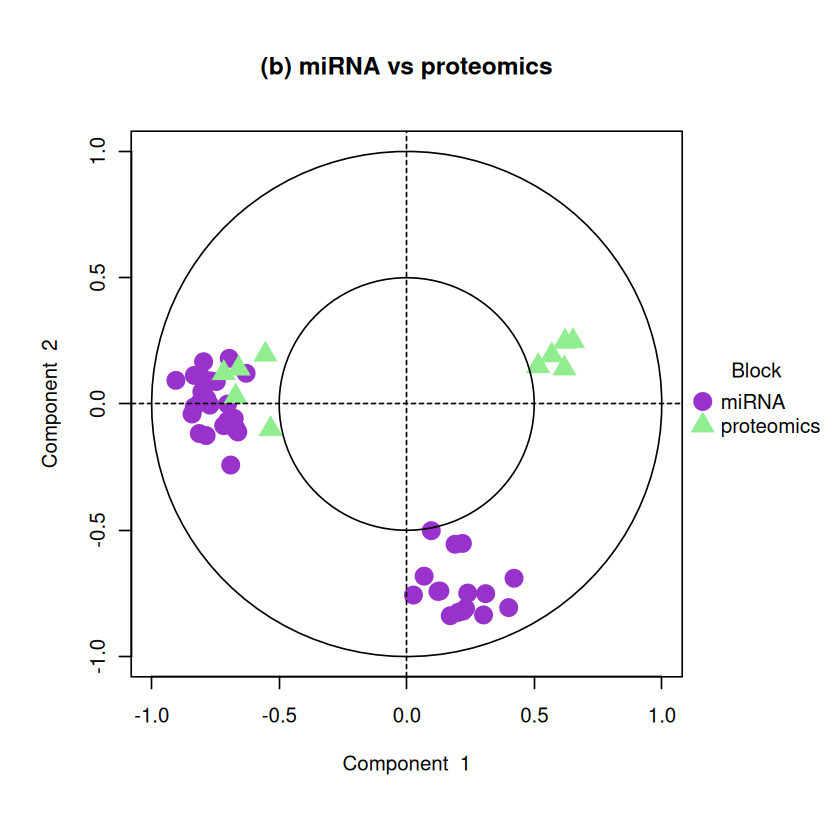

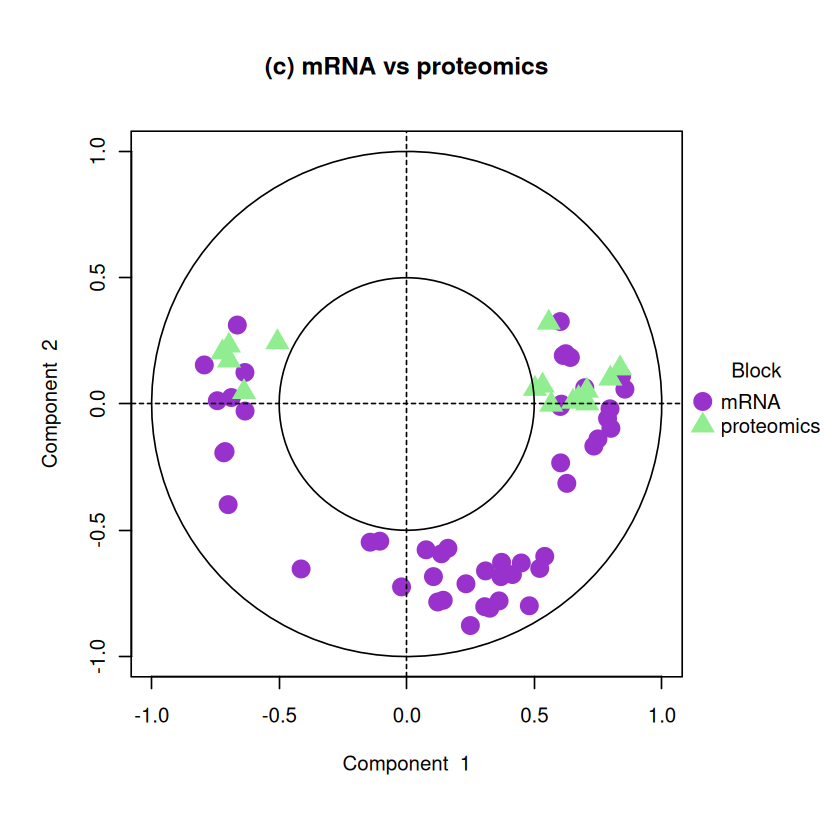

In [17]:
# Circle Correlation Plots for pairwise PLS models on the breast TCGA data. 
# Only displays the top 25 features for each dimension, subsetting by those with a correlation above 0.5.

# plot features of first PLS
plotVar(pls1, cutoff = 0.5, title = "(a) miRNA vs mRNA", 
        legend = c("miRNA", "mRNA"), 
        var.names = FALSE, style = 'graphics', 
        pch = c(16, 17), cex = c(2,2), 
        col = c('darkorchid', 'lightgreen'))

# plot features of second PLS
plotVar(pls2, cutoff = 0.5, title = "(b) miRNA vs proteomics", 
        legend = c("miRNA", "proteomics"), 
        var.names = FALSE, style = 'graphics', 
        pch = c(16, 17), cex = c(2,2), 
        col = c('darkorchid', 'lightgreen'))

# plot features of third PLS
plotVar(pls3, cutoff = 0.5, title = "(c) mRNA vs proteomics", 
        legend = c("mRNA", "proteomics"), 
        var.names = FALSE, style = 'graphics', 
        pch = c(16, 17), cex = c(2,2), 
        col = c('darkorchid', 'lightgreen'))

In [18]:
# Below is are correlations between the first component of each dataset for all three PLS models. 
# It can be seen the values are around ~0.8 - 0.9.

In [19]:
# calculate correlation of miRNA and mRNA
cor(pls1$variates$X, pls1$variates$Y) 

,comp1,comp2
comp1,0.88417918,-1.511654e-16
comp2,0.04929884,7.425733e-01


In [20]:
# calculate correlation of miRNA and proteins
cor(pls2$variates$X, pls2$variates$Y) 

,comp1,comp2
comp1,0.83619934,6.187928e-17
comp2,0.02358213,5.626135e-01


In [21]:
# calculate correlation of mRNA and proteins
cor(pls3$variates$X, pls3$variates$Y) 

,comp1,comp2
comp1,0.9360264,-1.751515e-17
comp2,-0.0181090,5.972544e-01


In [22]:
cat("Initial Model")

Initial Model

In [23]:
# for square matrix filled with 0.1s
design = matrix(0.1, 
                ncol = length(data), 
                nrow = length(data), 
                dimnames = list(names(data), names(data)))
diag(design) = 0 # set diagonal to 0s

design

# Creates a design matrix that specifies how strongly different datasets should be correlated:
# 0.1 = weak connection between all pairs
# Diagonal = 0 (dataset doesn't connect to itself)
# This is a good default starting point.

,miRNA,mRNA,proteomics
miRNA,0.0,0.1,0.1
mRNA,0.1,0.0,0.1
proteomics,0.1,0.1,0.0


In [24]:
# An arbitrarily high number of components (ncomp = 5) will be used.

basic.diablo.model = block.splsda(X = data, Y = Y, ncomp = 5, design = design) 

# Fits initial DIABLO model with 5 components (arbitrarily high to determine optimal number later). 
# block.splsda = multi-block sparse Partial Least Squares Discriminant Analysis.

Design matrix has changed to include Y; each block will be
            linked to Y.



In [25]:
cat("Tuning the number of components")

Tuning the number of components

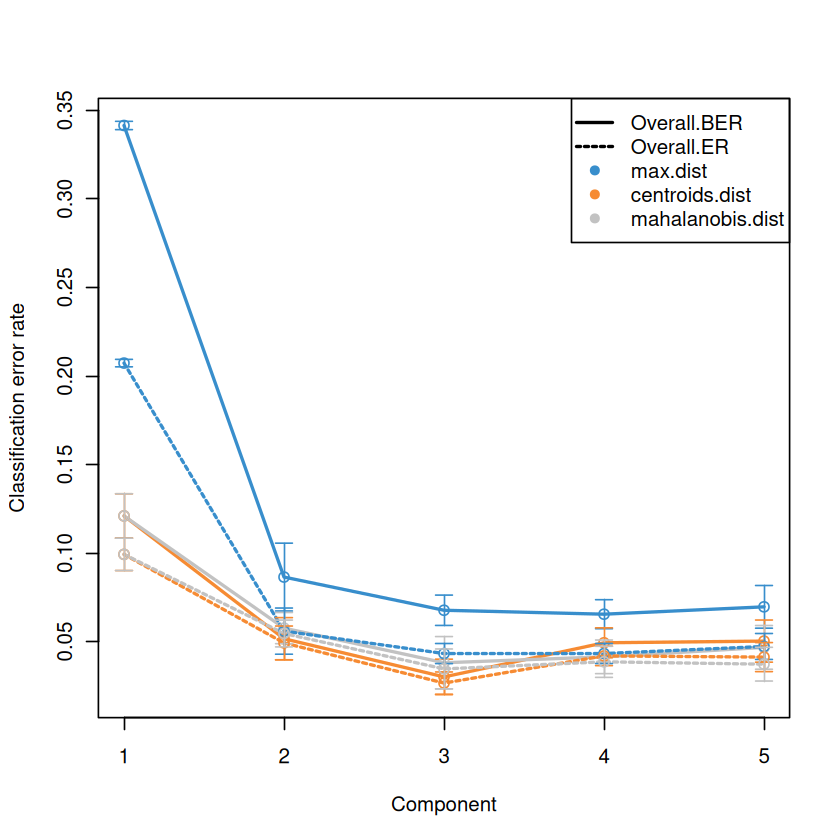

In [26]:
# run component number tuning with repeated CV
perf.diablo = perf(basic.diablo.model, 
                   validation = 'Mfold', 
                   folds = 10, nrepeat = 10) 

plot(perf.diablo) # plot output of tuning

# Performs 10-fold cross-validation repeated 10 times to assess model performance with different numbers of components. 
# This is a rigorous evaluation approach.

In [ ]:
# Choosing the number of components in block.plsda using perf() with 10 × 10-fold CV function in the breast.TCGA study. 
# Classification error rates (overall and balanced, see Section 7.3) are represented on the y-axis with respect 
# to the number of components on the x-axis for each prediction distance presented in PLS-DA

In [ ]:
# Both  overall and balanced error rate (BER) decrease from 1 to 2 components. 

In [27]:
# set the optimal ncomp value
ncomp = perf.diablo$choice.ncomp$WeightedVote["Overall.BER", "centroids.dist"] 
# show the optimal choice for ncomp for each dist metric
perf.diablo$choice.ncomp$WeightedVote 

,max.dist,centroids.dist,mahalanobis.dist
Overall.ER,3,3,3
Overall.BER,3,3,3


In [81]:
# Extracts the optimal number of components based on:

# Overall.BER = Balanced Error Rate (accounts for class imbalance)
# centroids.dist = distance metric used for classification
# WeightedVote = voting scheme for predictions

In [28]:
cat("Tuning the number of features")

Tuning the number of features

In [29]:
# set grid of values for each component to test
test.keepX = list (mRNA = c(5:9, seq(10, 18, 2), seq(20,30,5)), 
                   miRNA = c(5:9, seq(10, 18, 2), seq(20,30,5)),
                   proteomics = c(5:9, seq(10, 18, 2), seq(20,30,5)))

# Creates a grid of candidate values for the number of features to test:
# 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30
# This is a reasonable range for biomarker discovery.

# run the feature selection tuning
tune.TCGA = tune.block.splsda(X = data, 
                              Y = Y, 
                              ncomp = ncomp, 
                              test.keepX = test.keepX, 
                              design = design,
                              validation = 'Mfold', 
                              folds = 10, nrepeat = 1,
                              dist = "centroids.dist")

# This is computationally expensive - tests all combinations of feature numbers for each dataset to find optimal signature. 
# Note: only 1 repeat here (vs 10 earlier) to save time.

Design matrix has changed to include Y; each block will be
            linked to Y.


You have provided a sequence of keepX of length: 13 for block mRNA and 13 for block miRNA and 13 for block proteomics.
This results in 2197 models being fitted for each component and each nrepeat, this may take some time to run, be patient!


You can look into the 'BPPARAM' argument to speed up computation time.



In [32]:
list.keepX = tune.TCGA$choice.keepX # set the optimal values of features to retain
list.keepX

$miRNA
[1]  5  5 14

$mRNA
[1] 18 18 12

$proteomics
[1]  5 25  5

In [33]:
cat("Final model")

Final model

In [34]:
# set the optimised DIABLO model
final.diablo.model = block.splsda(X = data, 
                                  Y = Y, 
                                  ncomp = ncomp, 
                                  keepX = list.keepX, 
                                  design = design)

# Builds the final model with optimized parameters. This is the model you'll use for interpretation and prediction.

Design matrix has changed to include Y; each block will be
            linked to Y.



In [35]:
final.diablo.model$design 

,miRNA,mRNA,proteomics,Y
miRNA,0.0,0.1,0.1,1
mRNA,0.1,0.0,0.1,1
proteomics,0.1,0.1,0.0,1
Y,1.0,1.0,1.0,0


In [36]:
# The selected variables can be extracted with the function selectVar(), for example in the mRNA block, 
# as seen below. Note that the stability of selected variables can be extracted from the output of the perf() function.

In [37]:
# the features selected to form the first component
selectVar(final.diablo.model, block = 'mRNA', comp = 1)$mRNA$name 

[1] "ZNF552"  "KDM4B"   "PREX1"   "LRIG1"   "CCNA2"   "FUT8"    "TTC39A" 
 [8] "C4orf34" "ASPM"    "SLC43A3" "MEX3A"   "SEMA3C"  "STC2"    "E2F1"   
[15] "FMNL2"   "MED13L"  "LMO4"    "DTWD2"

In [ ]:
# Extracts names of selected features from mRNA dataset for component 1. These are your biomarker candidates.

In [38]:
cat("Plots")

Plots

In [39]:
# plotDIABLO() is a diagnostic plot to check whether the correlation between components from each data set 
# has been maximised as specified in the design matrix. 
# We specify which dimension to be assessed with the ncomp argument.

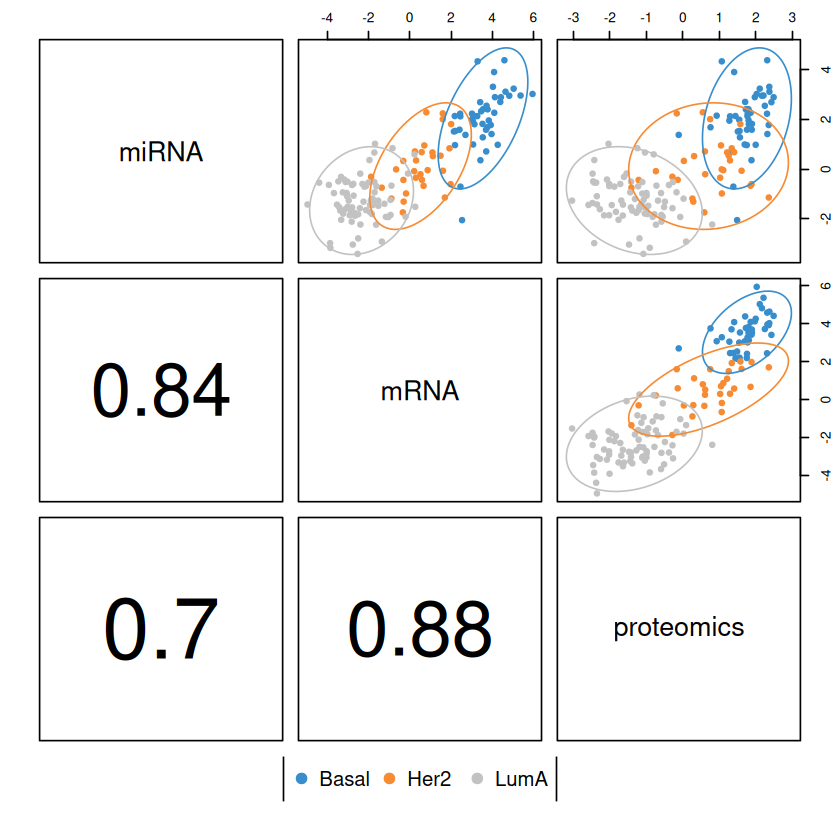

In [40]:
plotDiablo(final.diablo.model, ncomp = 1)

# Diagnostic plot showing how well components from each dataset correlate. Also shows sample separation by subtype with confidence ellipses.

In [41]:
# Diagnostic plot from multiblock sPLS-DA applied on the breast.TCGA study. 
# Samples are represented based on the specified component (here ncomp = 1) 
# for each data set (mRNA, miRNA and protein). 
# Samples are coloured by breast cancer subtype and 95% confidence ellipse plots are represented.

In [42]:
# The first components from each data set are highly correlated to each other (indicated by the large numbers in the bottom left). 
# The colours and ellipses related to the sample subtypes indicate the discriminative power of each component to separate 
# the different tumour subtypes. 

# For the first component, the centroids of each subtype are distinct 
# but there is a moderate amount of overlap between each sample group in their confidence ellipses.

In [43]:
# plotIndiv() function projects each sample into the space spanned by the components of each block.

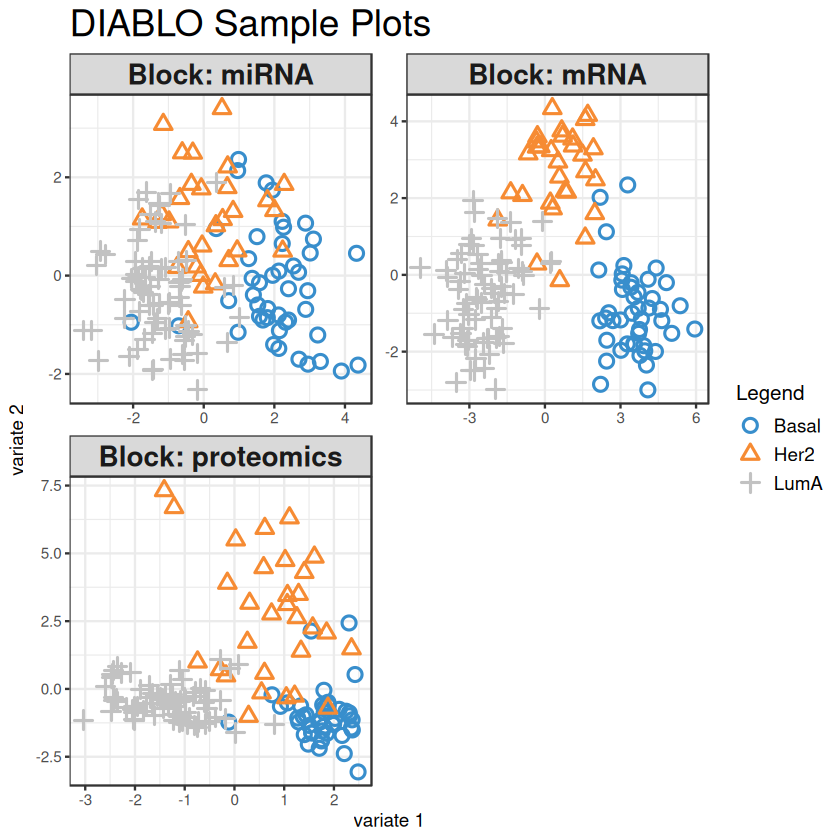

In [82]:
plotIndiv(final.diablo.model, 
          ind.names = FALSE, 
          legend = TRUE, 
          title = 'DIABLO Sample Plots')


# Sample plot - shows where each sample projects in the component space for each omics layer. 
# Helps visualize sample clustering by subtype.

In [45]:
# Sample plot from multiblock sPLS-DA performed on the breast.TCGA study. 
# The samples are plotted according to their scores on the first 2 components for each data set. 
# Samples are coloured by cancer subtype

In [83]:
# Arrow plot - shows agreement between datasets at the sample level:

# Arrow start = centroid across all datasets for a sample
# Arrow tips = sample position in each individual dataset
# Short arrows = good agreement between omics layers

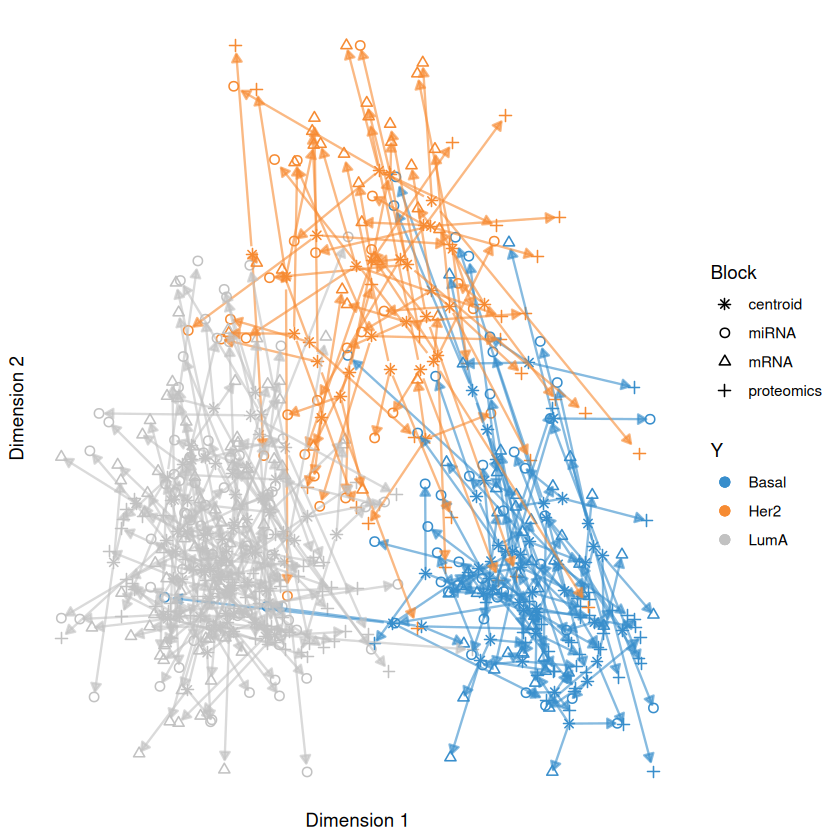

In [47]:
plotArrow(final.diablo.model, 
          ind.names = FALSE, 
          legend = TRUE, 
          title = 'mixomics')

In [48]:
# The start of the arrow indicates the centroid between all data sets for a given sample and the tips of the arrows 
# indicate the location of that sample in each block. 
# Such graphics highlight the agreement between all data sets at the sample level. 

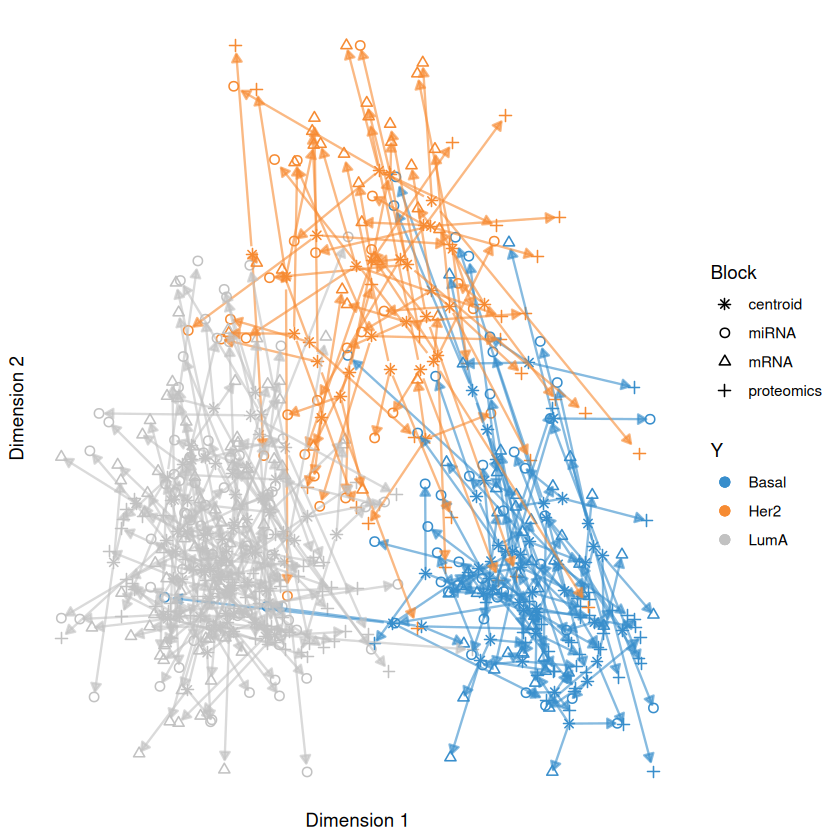

In [49]:
plotArrow(final.diablo.model, 
          ind.names = FALSE, 
          legend = TRUE, 
          title = 'DIABLO')

In [50]:
cat("Variable plots")

Variable plots

In [ ]:
# A majority of the miRNA variables are positively correlated with the first component while the mRNA variables seem 
# to separate along this dimension. 
# These first two components correlate highly with the selected variables from the proteomics dataset. 
# From this, the correlation of each selected feature from all three datasets can be evaluated based on their proximity.

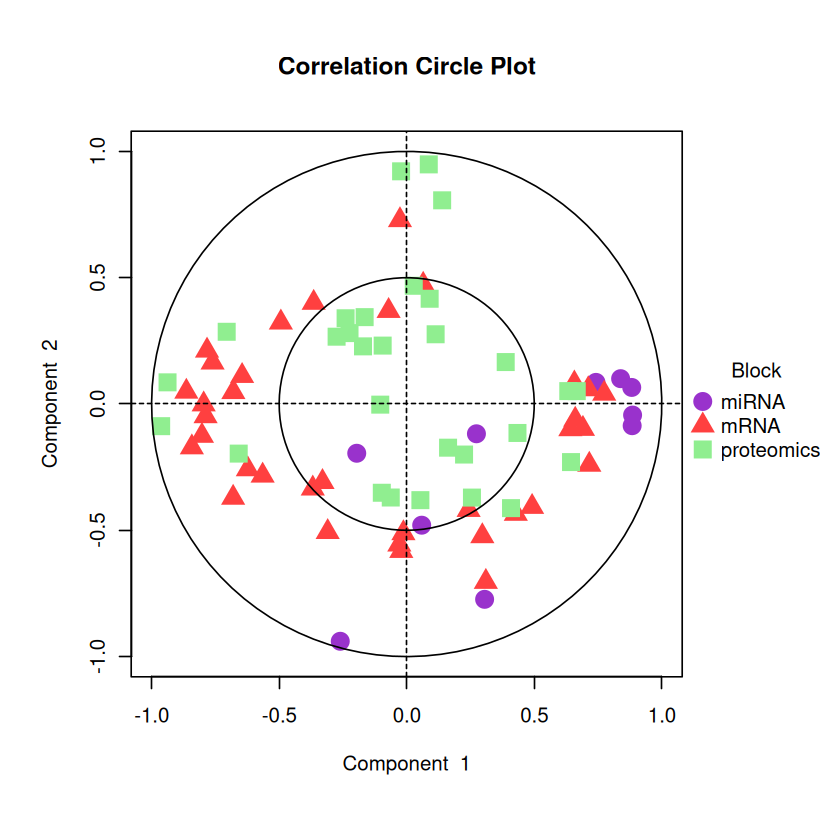

In [51]:
plotVar(final.diablo.model, var.names = FALSE, 
        style = 'graphics', legend = TRUE,
        pch = c(16, 17, 15), cex = c(2,2,2), 
        col = c('darkorchid', 'brown1', 'lightgreen'))

In [84]:
# Shows selected features from all datasets in correlation circle.
# Features close together are highly correlated across omics layers.

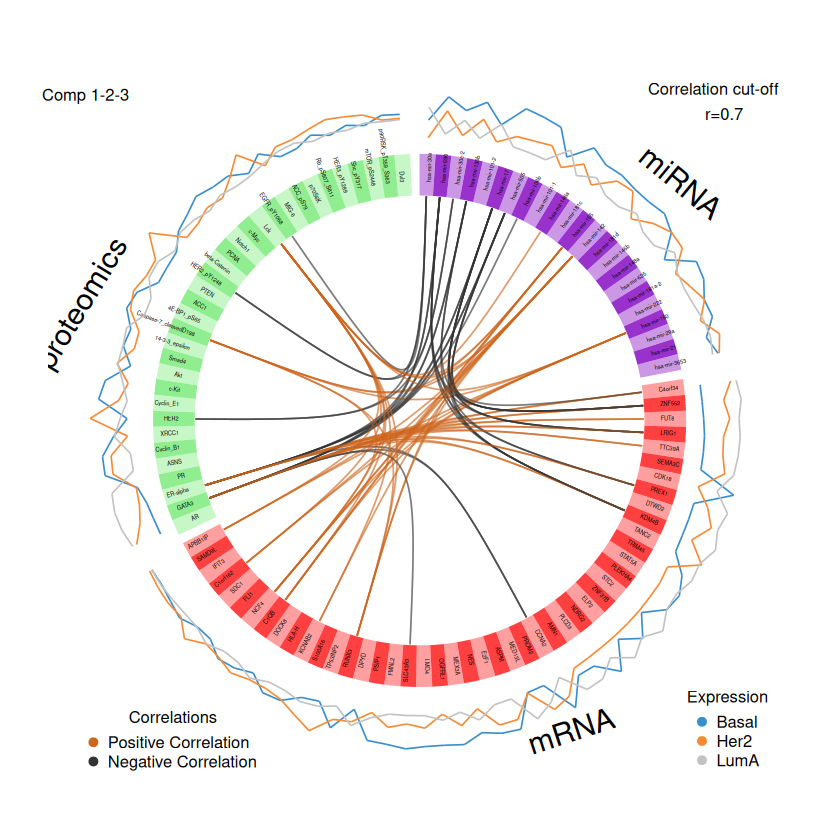

In [52]:
circosPlot(final.diablo.model, cutoff = 0.7, line = TRUE,
           color.blocks= c('darkorchid', 'brown1', 'lightgreen'),
           color.cor = c("chocolate3","grey20"), size.labels = 1.5)

# Circos plot - elegant visualization showing correlations > 0.7 between features from different datasets. 
# Each arc connects correlated features.

In [91]:
# Another visualisation of the correlations between the different types of variables is the relevance network, 
# which is also built on the similarity matrix (as is the circos plot). Each colour represents a type of variable.

# Same optimally selected features, but only connections where correlation > 0.7 are drawn.

# Example: A line between miRNA "hsa-mir-200c" and mRNA "ZEB1" means:

# These are both in the final signature
# They're correlated > 0.7 across samples
# Biological interpretation: miR-200c might regulate ZEB1 (known tumor suppressor relationship)

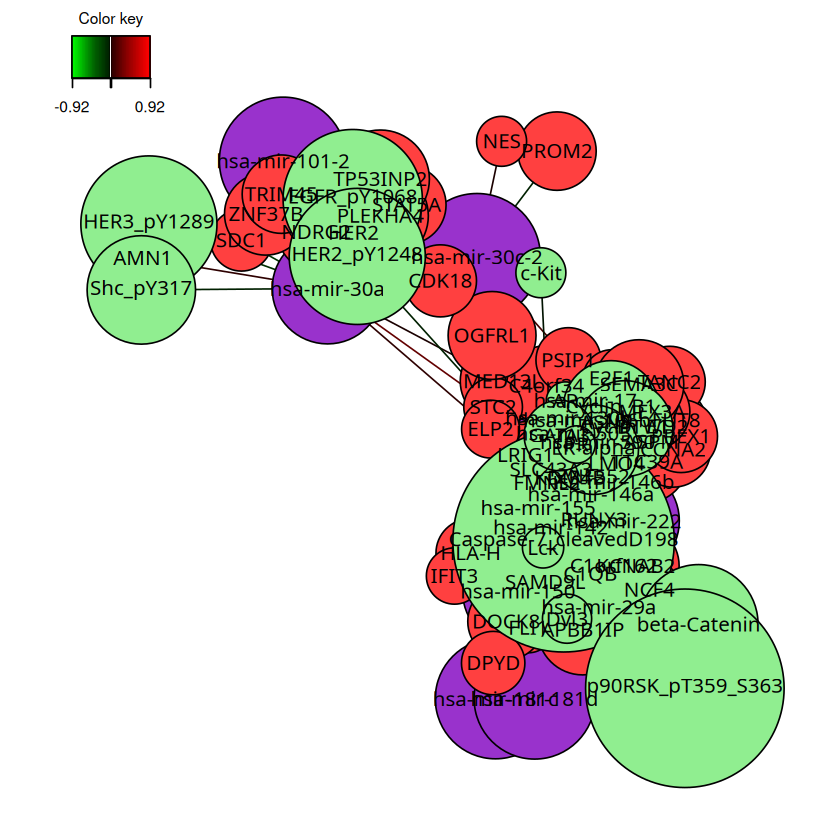

In [92]:
network(final.diablo.model, 
        blocks = c(1,2,3),
        color.node = c('darkorchid', 'brown1', 'lightgreen'), cutoff = 0.4)

# Creates network graph where:

# Nodes = features (colored by omics type)
# Edges = correlations > 0.4
# Shows multi-omics regulatory networks.

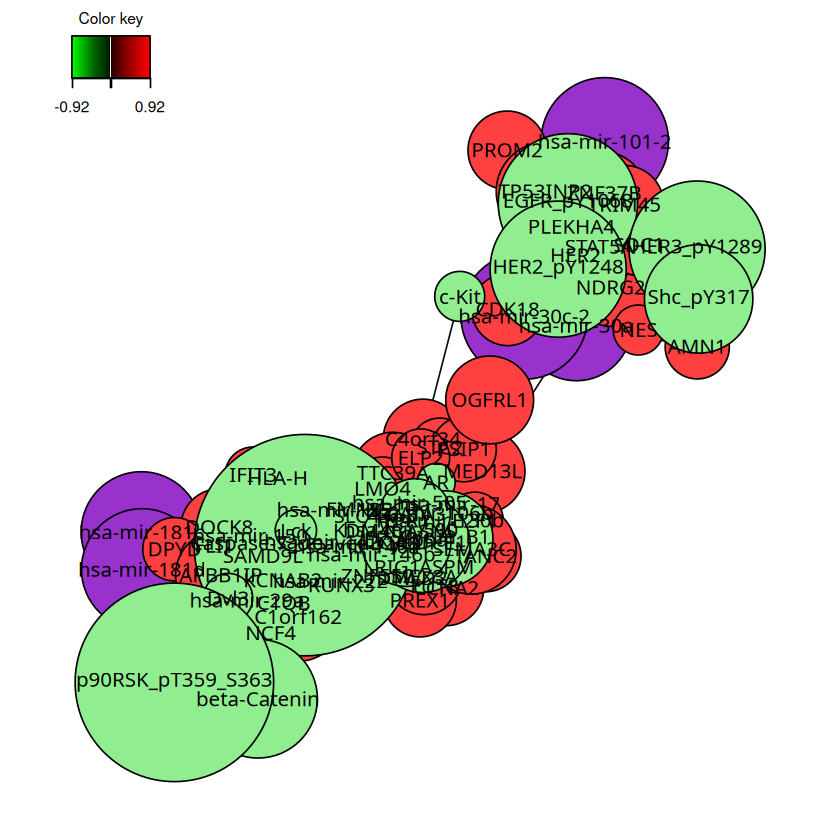

In [93]:
library(igraph)
my.network = network(final.diablo.model, 
                     blocks = c(1,2,3),
                     color.node = c('darkorchid', 'brown1', 'lightgreen'), cutoff = 0.4)
write.graph(my.network$gR, file = "myNetwork.gml", format = "gml")

# Features shown: Same selected features, but with lower cutoff (0.4 vs 0.7), so more connections.
# Nodes = individual features (miRNAs, mRNAs, proteins)
# Edges = correlations > 0.4

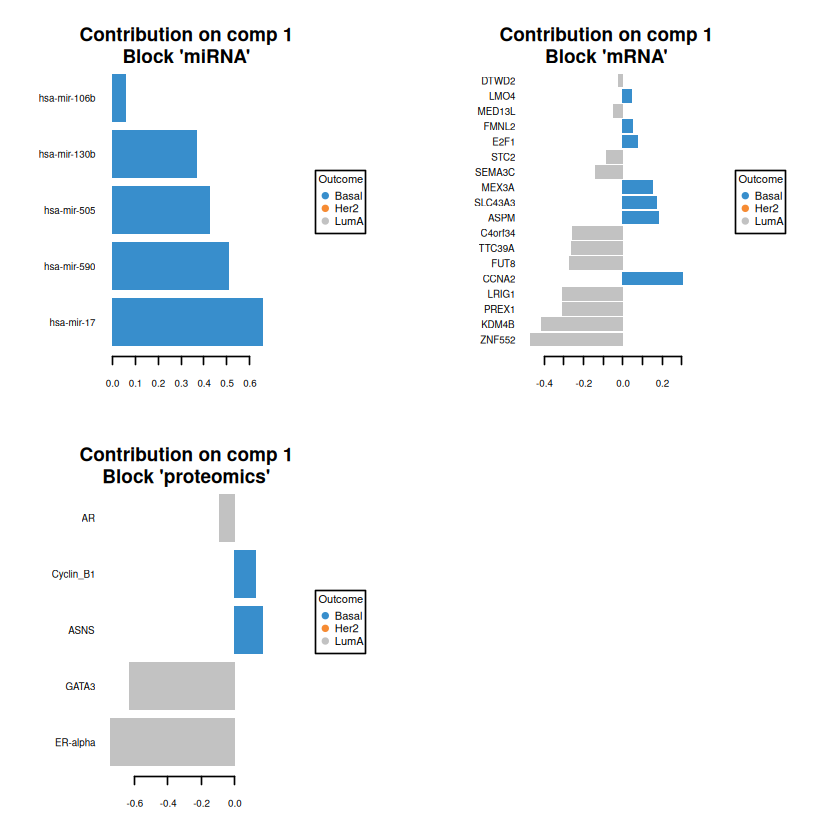

In [94]:
plotLoadings(final.diablo.model, comp = 1, contrib = 'max', method = 'median')

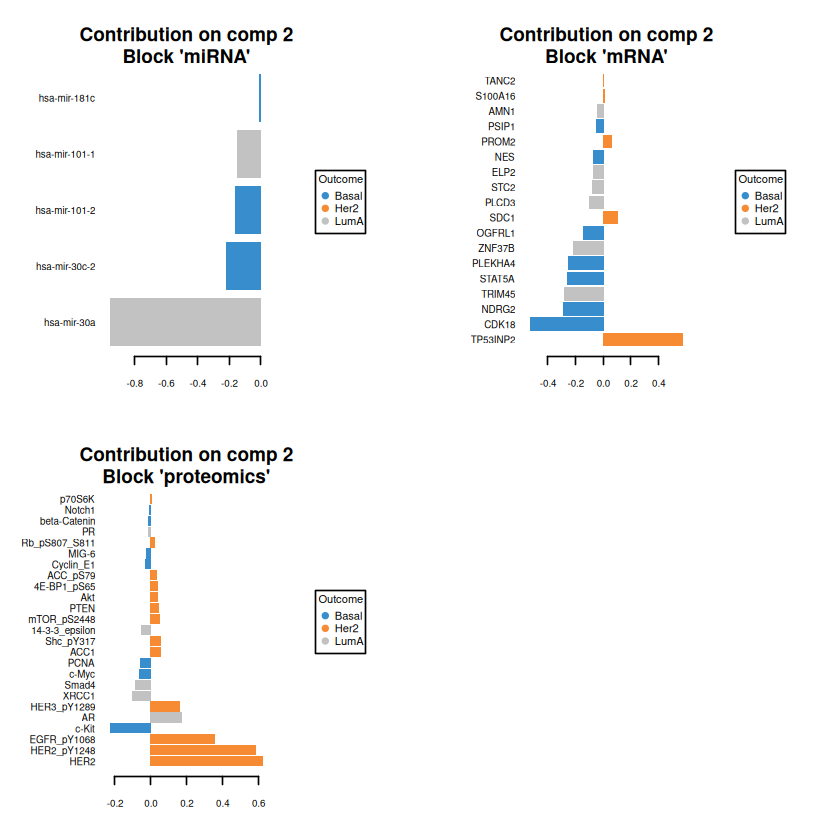

In [56]:
plotLoadings(final.diablo.model, comp = 2, contrib = 'max', method = 'median')

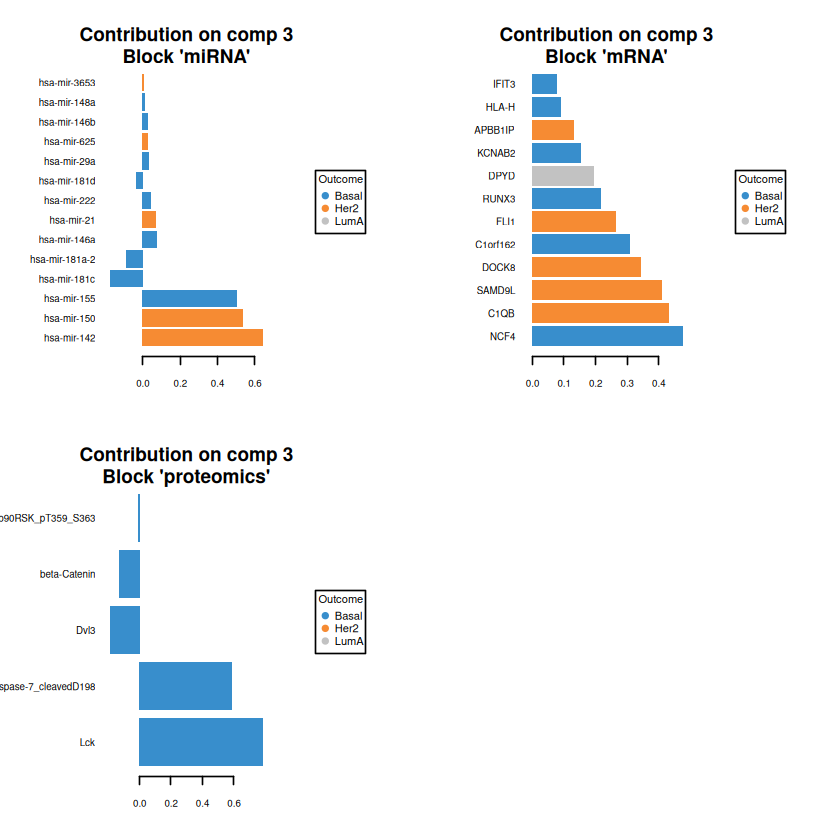

In [95]:
plotLoadings(final.diablo.model, comp = 3, contrib = 'max', method = 'median')

In [97]:
# Key Insight:

# The number of features decreases through the analysis:

# Start: All features in original data
# miRNA: ~184 features
# mRNA: ~200 features
# Proteomics: ~142 features

# Pairwise PLS: 25 features per dataset (arbitrary)
# After tuning (line 125): Optimal number (might be 8 mRNA, 12 miRNA, 10 proteins)
# Final plots: Only these optimized features appear

In [57]:
# The cimDIABLO() function is a clustered image map specifically implemented 
# to represent the multi-omics molecular signature expression for each sample


trimming values to [-3, 3] range for cim visualisation. See 'trim' arg in ?cimDiablo


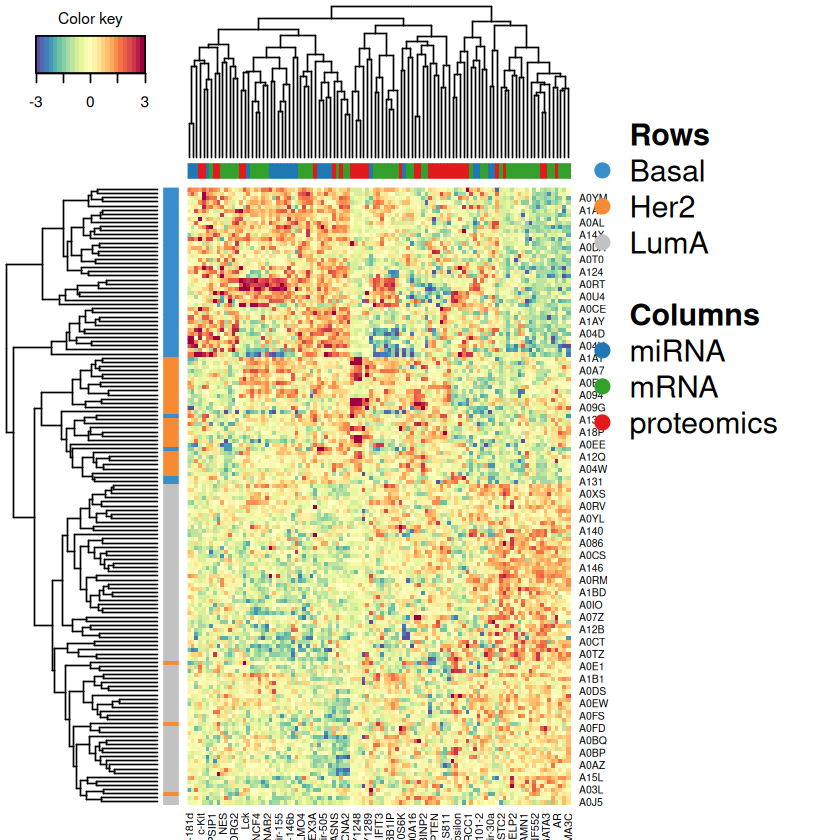

In [58]:
cimDiablo(final.diablo.model)

# Clustered heatmap showing expression of selected features across all samples. Helps identify multi-omics signatures for each subtype.

In [98]:
cat("Performance of the model")

Performance of the model

In [60]:
# We assess the performance of the model using 10-fold cross-validation repeated 10 times, using the function perf(). 
# The method runs a block.splsda() model on the pre-specified arguments input from the final.diablo.model object, 
# but on cross-validated samples. We then assess the accuracy of the prediction on the left-out samples.

In [61]:
# Since the tune() function was used with the centroid.dist argument, 
# the outputs of the perf() function for that same distance are examined. 

In [62]:
# run repeated CV performance evaluation
perf.diablo = perf(final.diablo.model, 
                   validation = 'Mfold', 
                   M = 10, nrepeat = 10, 
                   dist = 'centroids.dist') 

perf.diablo$MajorityVote.error.rate

# Final rigorous evaluation - 10×10 CV on the optimized model to get reliable performance estimates.

,comp1,comp2,comp3
Basal,0.03333333,0.04000000,0.06000000
Her2,0.26666667,0.19000000,0.16333333
LumA,0.06266667,0.03200000,0.03600000
Overall.ER,0.09466667,0.06600000,0.06866667
Overall.BER,0.12088889,0.08733333,0.08644444


In [85]:
perf.diablo$WeightedVote.error.rate

# Shows classification error rates using two voting schemes:
# MajorityVote - each dataset gets equal vote
# WeightedVote - datasets weighted by performance

,comp1,comp2,comp3
Basal,0.03333333,0.04000000,0.05555556
Her2,0.22333333,0.16333333,0.14666667
LumA,0.06266667,0.02400000,0.02800000
Overall.ER,0.08600000,0.05666667,0.06000000
Overall.BER,0.10644444,0.07577778,0.07674074


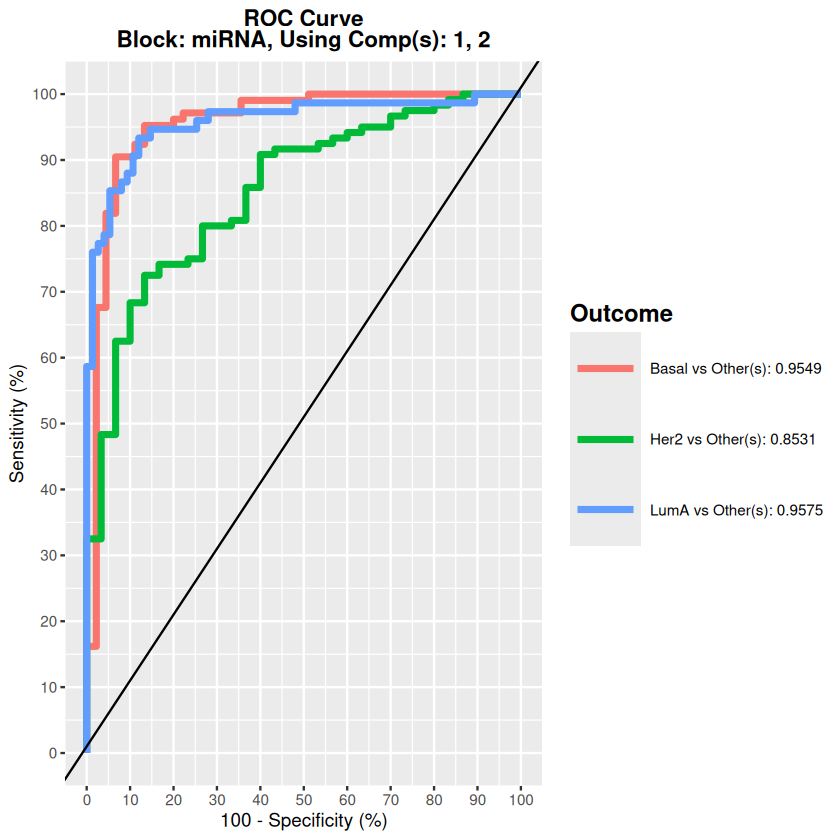

In [64]:
auc.splsda = auroc(final.diablo.model, 
                   roc.block = "miRNA", 
                   roc.comp = 2, 
                   print = FALSE)

# Computes AUC-ROC curves for the miRNA block. Good for assessing discriminative power for multi-class problems.

In [66]:
cat("Prediction on an external test set")

Prediction on an external test set

In [ ]:
# The predict() function predicts the class of samples from a test set. 
# In our specific case, one data set is missing in the test set but the method can still be applied. 
# Make sure the name of the blocks correspond exactly.

In [86]:
data.test.TCGA = list(mRNA = breast.TCGA$data.test$mrna,
                      miRNA = breast.TCGA$data.test$mirna)

predict.diablo = predict(final.diablo.model, newdata = data.test.TCGA)

Warning message in predict.block.spls(final.diablo.model, newdata = data.test.TCGA):
“Some blocks are missing in 'newdata'; the prediction is based on the following blocks only: miRNA, mRNA”


In [87]:
confusion.mat = get.confusion_matrix(truth = breast.TCGA$data.test$subtype,
                                     predicted = predict.diablo$WeightedVote$centroids.dist[,2])
confusion.mat

,predicted.as.Basal,predicted.as.Her2,predicted.as.LumA
Basal,20,1,0
Her2,0,14,0
LumA,0,1,34


In [88]:
get.BER(confusion.mat)

[1] 0.02539683

In [ ]:
cat("

Do We Want High Correlations Between Omics Layers?

It depends on your goal! This is nuanced:

High correlations (~0.8-0.9) are GOOD when:

Biological coherence: Different omics layers measuring the same biological process should be correlated

Example: mRNA → protein translation

If mRNA levels are high, protein levels should be high too

High correlation = the biology makes sense

Data quality: High correlations suggest:

Your measurements are reliable
Technical variation is low
The datasets are measuring real biological signal

Integration success: The model successfully found:

Common patterns across omics layers
Coordinated molecular changes
Multi-omics signatures

But you DON'T want TOO high correlation because:

Redundancy: If correlation = 1.0, the datasets provide identical information

You're not gaining anything from multi-omics
Just use one dataset

Loss of complementarity: Each omics layer should provide unique information

miRNA regulates genes (regulatory info)
mRNA shows transcription (gene expression)
Proteins show final functional molecules (functional info)
You want ~0.7-0.9 correlation (related but not identical)

")

# design = matrix(0.1, ncol = length(data), nrow = length(data))
# The 0.1 design matrix is actually quite weak. This tells DIABLO:

# "Find components that are somewhat correlated between datasets"
# "But prioritize discrimination of cancer subtypes"

# You could increase this to 0.5 or 0.7 if you want stronger integration, but 0.1 is a good starting point.
# The observed correlations of 0.8-0.9 from the pairwise PLS models (lines 67-73) are actually results, not input. 

# This means:

# Even with weak constraints (0.1), the data naturally shows strong relationships
# This is good - it validates that your omics layers are biologically connected

In [99]:
cat("What Makes Them Biomarkers? 

1. They Discriminate Between Disease States

The DIABLO model selects features that best separate the different breast cancer subtypes. 

Look at what the model does:

final.diablo.model = block.splsda(X = data, Y = Y, ...)

where Y = breast cancer subtype (Basal, Her2, LumA, LumB, Normal)

The model asks: 'Which miRNAs, mRNAs, and proteins differ most between these cancer subtypes?'

Features are selected because:

Basal subtype patients have high expression of certain features
Her2 subtype patients have different expression patterns
LumA/LumB patients have yet different patterns

2. They're Statistically Validated Through Cross-Validation

tune.TCGA = tune.block.splsda(..., validation = 'Mfold', folds = 10, nrepeat = 1)

Features are only kept if they consistently predict cancer subtype across different data splits

This means:

They're not just noise or random fluctuations
They're reproducible predictors
They generalize to new samples

3. They're Part of a Multi-Omics Signature

Unlike single-omics analysis, DIABLO selects features that are:

Biologically coherent across multiple molecular levels:

circosPlot(final.diablo.model, cutoff = 0.7, ...)

If you see connections between:

miRNA 'hsa-mir-21' (purple)
mRNA 'PTEN' (brown)
Protein 'PTEN' (green)

This suggests a regulatory cascade:

miR-21 regulates PTEN mRNA

PTEN mRNA produces PTEN protein

This entire pathway differs between cancer subtypes

")

What Makes Them Biomarkers? 

1. They Discriminate Between Disease States

The DIABLO model selects features that best separate the different breast cancer subtypes. 

Look at what the model does:

final.diablo.model = block.splsda(X = data, Y = Y, ...)

where Y = breast cancer subtype (Basal, Her2, LumA, LumB, Normal)

The model asks: 'Which miRNAs, mRNAs, and proteins differ most between these cancer subtypes?'

Features are selected because:

Basal subtype patients have high expression of certain features
Her2 subtype patients have different expression patterns
LumA/LumB patients have yet different patterns

2. They're Statistically Validated Through Cross-Validation

tune.TCGA = tune.block.splsda(..., validation = 'Mfold', folds = 10, nrepeat = 1)

Features are only kept if they consistently predict cancer subtype across different data splits

This means:

They're not just noise or random fluctuations
They're reproducible predictors
They generalize to new samples

3. They're Part o

In [100]:
# This is MORE meaningful than individual markers because:

# It captures biological mechanisms (not just associations)
# It's more robust (multiple correlated measurements)
# It's more likely to be causal (not just correlation)